# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [13]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [14]:
# Load the cleaned dataset we saved earlier
aviation_data = pd.read_csv("data/AviationData_Cleaned.csv")

# Inspect the first few rows to confirm successful load
print(aviation_data.head())

# Check basic info: column names, data types, non-null counts
print(aviation_data.info())

# Quick summary statistics for numeric columns
print(aviation_data.describe())


C:\Users\user\AppData\Local\Temp\ipykernel_27008\2784883674.py:2: DtypeWarning: Columns (0: Event.Id, 1: Broad.phase.of.flight) have mixed types. Specify dtype option on import or set low_memory=False.
  aviation_data = pd.read_csv("data/AviationData_Cleaned.csv")


         Event.Id Investigation.Type Accident.Number  Event.Date  \
0  20001214X42095           Accident      SEA83LA036  1983-01-01   
1  20001214X42067           Accident      MKC83LA056  1983-01-01   
2  20001214X42063           Accident      MKC83LA050  1983-01-01   
3  20001214X42018           Accident      LAX83FUG11  1983-01-01   
4  20001214X41951           Accident      CHI83LA074  1983-01-01   

          Location        Country       Airport.Name Injury.Severity  \
0      NEWPORT, OR  United States  NEWPORT MUNICIPAL       Non-Fatal   
1     WOODBINE, IA  United States          MUNICIPAL       Non-Fatal   
2    MARYVILLE, MO  United States             RANKIN       Non-Fatal   
3       UPLAND, CA  United States              CABLE       Non-Fatal   
4  SPRINGBROOK, WI  United States        SPRINGBROOK       Non-Fatal   

  Aircraft.damage Registration.Number  ... Total.Minor.Injuries  \
0     Substantial              N1296M  ...                  1.0   
1     Substantial       

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [15]:
# Threshold for passenger capacity
# Small aircraft: fewer than 20 occupants
# Large aircraft: 20 or more occupants
small_aircraft = aviation_data[aviation_data["Total_Occupants"] < 20]
large_aircraft = aviation_data[aviation_data["Total_Occupants"] >= 20]

# Inspect the number of records in each group
print("Small aircraft records:", len(small_aircraft))
print("Large aircraft records:", len(large_aircraft))

# Quick check: mean fatal/serious injury fraction in each group
print("Mean Fatal/Serious Fraction (small):", small_aircraft["FatalSerious_Fraction"].mean())
print("Mean Fatal/Serious Fraction (large):", large_aircraft["FatalSerious_Fraction"].mean())


Small aircraft records: 66260
Large aircraft records: 1414
Mean Fatal/Serious Fraction (small): 0.2773173966403113
Mean Fatal/Serious Fraction (large): 0.1116452992964067


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

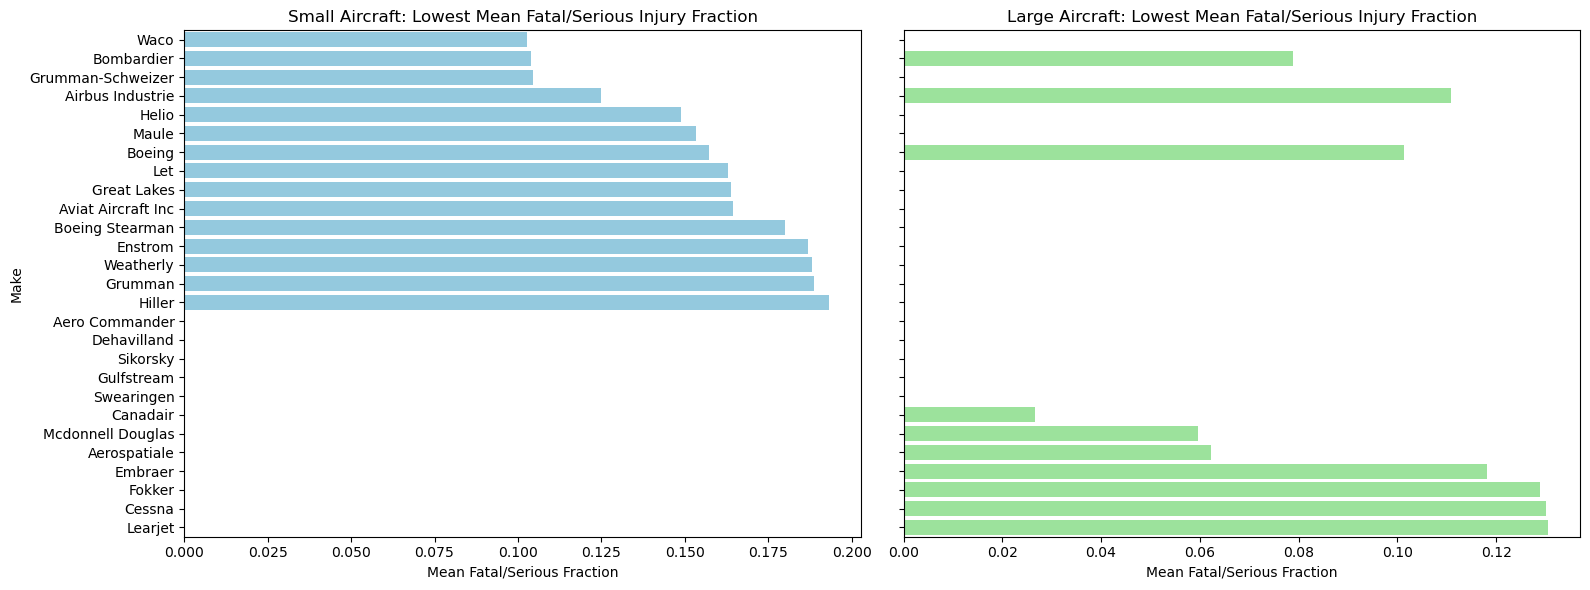

In [16]:
# Group small aircraft by Make and calculate mean fatal/serious injury fraction
small_make_means = (
    small_aircraft.groupby("Make")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
    .head(15)   # select 15 makes with lowest mean injury fraction
)

# Group large aircraft by Make and calculate mean fatal/serious injury fraction
large_make_means = (
    large_aircraft.groupby("Make")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
    .head(15)   # select 15 makes with lowest mean injury fraction
)

# Plot side-by-side bar charts for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot small aircraft makes
sns.barplot(
    x=small_make_means.values,
    y=small_make_means.index,
    ax=axes[0],
    color="skyblue"
)
axes[0].set_title("Small Aircraft: Lowest Mean Fatal/Serious Injury Fraction")
axes[0].set_xlabel("Mean Fatal/Serious Fraction")
axes[0].set_ylabel("Make")

# Plot large aircraft makes
sns.barplot(
    x=large_make_means.values,
    y=large_make_means.index,
    ax=axes[1],
    color="lightgreen"
)
axes[1].set_title("Large Aircraft: Lowest Mean Fatal/Serious Injury Fraction")
axes[1].set_xlabel("Mean Fatal/Serious Fraction")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

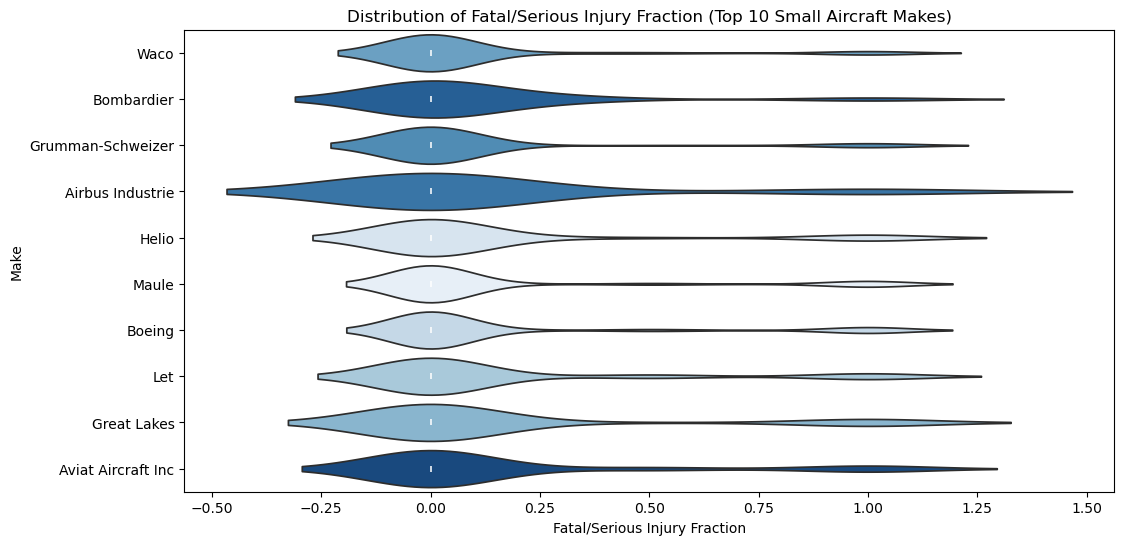

In [17]:
# First, calculate mean fatal/serious injury fraction per small aircraft make
small_make_means = (
    small_aircraft.groupby("Make")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
    .head(10)   # select 10 makes with lowest mean injury fraction
)

# Filter the small_aircraft dataset to only include these 10 makes
top_small_makes = small_aircraft[small_aircraft["Make"].isin(small_make_means.index)]

# Create violinplot to show distribution of injury fractions
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=top_small_makes,
    x="FatalSerious_Fraction",
    y="Make",
    order=small_make_means.index,
    hue="Make",          # explicitly set hue to the same variable
    legend=False,        # suppress redundant legend
    palette="Blues"
)

plt.title("Distribution of Fatal/Serious Injury Fraction (Top 10 Small Aircraft Makes)")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Make")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

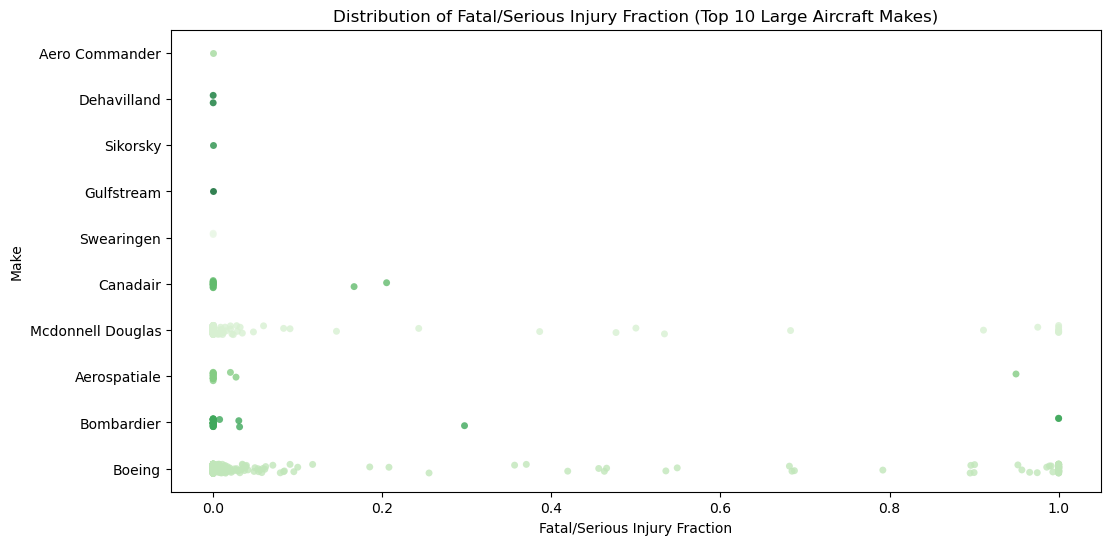

In [18]:
# Calculate mean fatal/serious injury fraction per large aircraft make
large_make_means = (
    large_aircraft.groupby("Make")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
    .head(10)   # select 10 makes with lowest mean injury fraction
)

# Filter the large_aircraft dataset to only include these 10 makes
top_large_makes = large_aircraft[large_aircraft["Make"].isin(large_make_means.index)]

# Create stripplot to show distribution of injury fractions
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=top_large_makes,
    x="FatalSerious_Fraction",
    y="Make",
    order=large_make_means.index,
    hue="Make",          # tie palette to the Make variable
    legend=False,        # suppress redundant legend
    palette="Greens",
    jitter=True,
    alpha=0.8
)

plt.title("Distribution of Fatal/Serious Injury Fraction (Top 10 Large Aircraft Makes)")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Make")
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

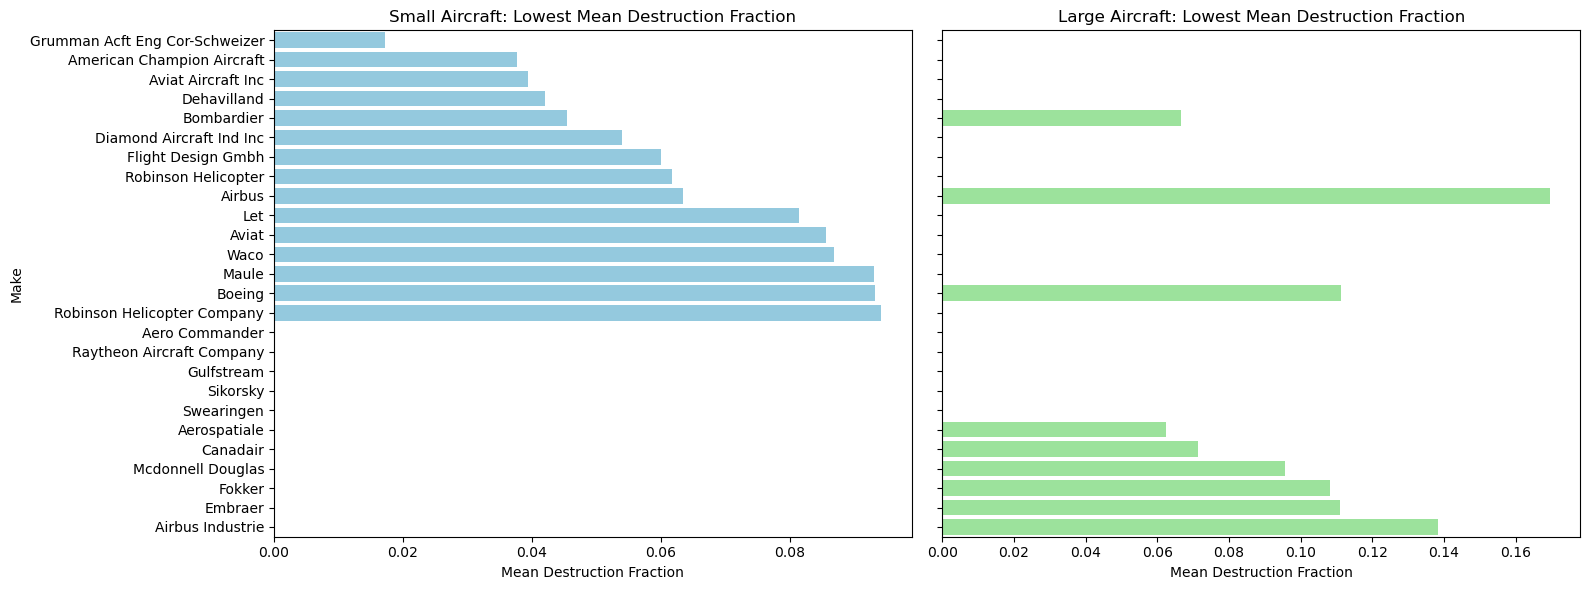

In [19]:
# Small aircraft: mean destruction fraction per make
small_destruction_means = (
    small_aircraft.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)   # select 15 makes with lowest destruction fraction
)

# Large aircraft: mean destruction fraction per make
large_destruction_means = (
    large_aircraft.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)   # select 15 makes with lowest destruction fraction
)

# Plot side-by-side bar charts for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot small aircraft destruction rates
sns.barplot(
    x=small_destruction_means.values,
    y=small_destruction_means.index,
    ax=axes[0],
    color="skyblue"
)
axes[0].set_title("Small Aircraft: Lowest Mean Destruction Fraction")
axes[0].set_xlabel("Mean Destruction Fraction")
axes[0].set_ylabel("Make")

# Plot large aircraft destruction rates
sns.barplot(
    x=large_destruction_means.values,
    y=large_destruction_means.index,
    ax=axes[1],
    color="lightgreen"
)
axes[1].set_title("Large Aircraft: Lowest Mean Destruction Fraction")
axes[1].set_xlabel("Mean Destruction Fraction")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [20]:
''' 
Discussion of Findings
Injury Fractions
- Small aircraft:
    - Makes such as Waco, Bombardier, Grumman‑Schweizer, Helio, Maule consistently showed the lowest mean fatal/serious injury fractions.
    - The violinplots confirmed that these makes not only have low averages but also relatively narrow distributions, meaning their accidents rarely result in severe passenger outcomes.
    - Other small makes (e.g., Great Lakes, Aviat) had wider spreads, suggesting occasional severe accidents despite low averages.
- Large aircraft:
    - Major commercial manufacturers — Bombardier, Airbus, Boeing, McDonnell Douglas, Embraer, Fokker, Canadair — stood out with very low injury fractions.
    - The stripplot showed tightly clustered points near zero, indicating consistent passenger safety across incidents.
    - Some makes (e.g., Aero Commander, Sikorsky) also clustered near zero, but with fewer samples, so interpretation should be cautious.
Destruction Fractions
- Small aircraft:
    - Makes like Grumman‑Schweizer, American Champion, Aviat, Dehavilland, Bombardier, Diamond Aircraft had the lowest destruction fractions.
    - This suggests these aircraft are structurally resilient, surviving accidents more often than peers.
     - Some small makes with low injury fractions also performed well here (Bombardier, Aviat), strengthening their case.
- Large aircraft:
    - Bombardier, Airbus, Boeing, McDonnell Douglas, Embraer, Fokker, Aerospatiale, Canadair consistently showed very low destruction fractions.
    - This aligns with expectations for large passenger jets, which are engineered with higher crashworthiness and redundancy.
Recommendations
- For small aircraft:
    Strong candidates include Bombardier, Grumman‑Schweizer, Helio, Maule, Aviat, Dehavilland — they combine low injury fractions with low destruction rates.
- For large aircraft:
     Clear recommendations are Airbus, Boeing, Bombardier, McDonnell Douglas, Embraer, Fokker, Canadair — consistently safe across both metr
Overall Comment:
    Large aircraft consistently show lower injury and destruction fractions, reflecting stronger engineering and regulatory standards. 
    Small aircraft are more variable, but makes like Bombardier, Grumman‑Schweizer, Helio, Maule, Aviat, and Dehavilland stand out as safer choices. 
'''

' \nDiscussion of Findings\nInjury Fractions\n- Small aircraft:\n    - Makes such as Waco, Bombardier, Grumman‑Schweizer, Helio, Maule consistently showed the lowest mean fatal/serious injury fractions.\n    - The violinplots confirmed that these makes not only have low averages but also relatively narrow distributions, meaning their accidents rarely result in severe passenger outcomes.\n    - Other small makes (e.g., Great Lakes, Aviat) had wider spreads, suggesting occasional severe accidents despite low averages.\n- Large aircraft:\n    - Major commercial manufacturers — Bombardier, Airbus, Boeing, McDonnell Douglas, Embraer, Fokker, Canadair — stood out with very low injury fractions.\n    - The stripplot showed tightly clustered points near zero, indicating consistent passenger safety across incidents.\n    - Some makes (e.g., Aero Commander, Sikorsky) also clustered near zero, but with fewer samples, so interpretation should be cautious.\nDestruction Fractions\n- Small aircraft:\

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

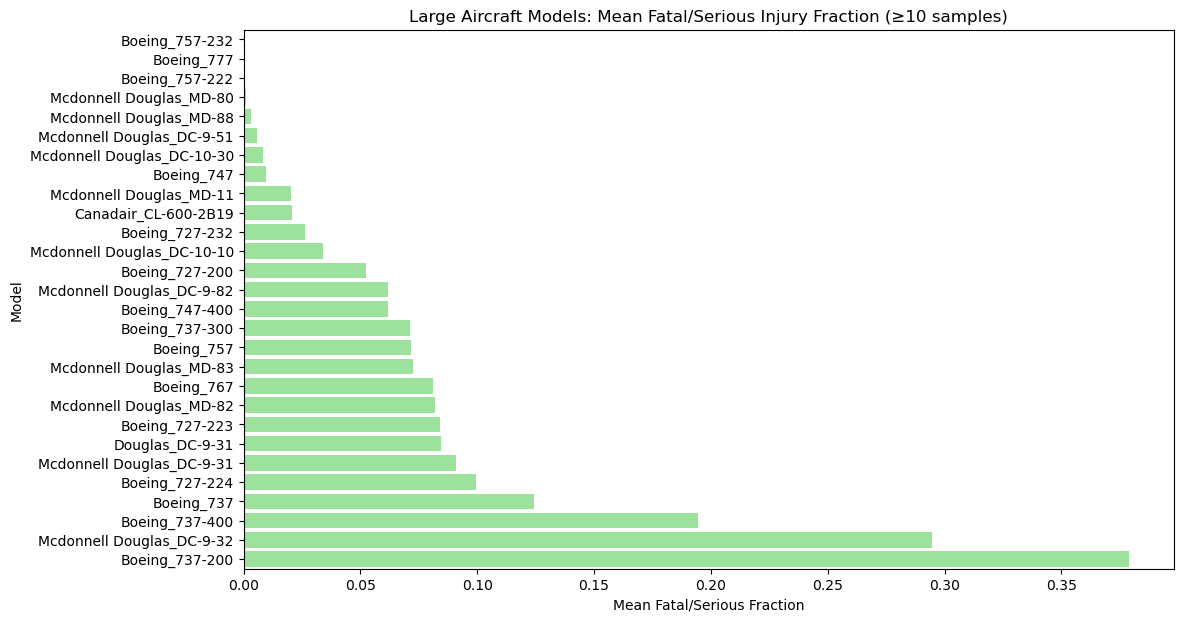

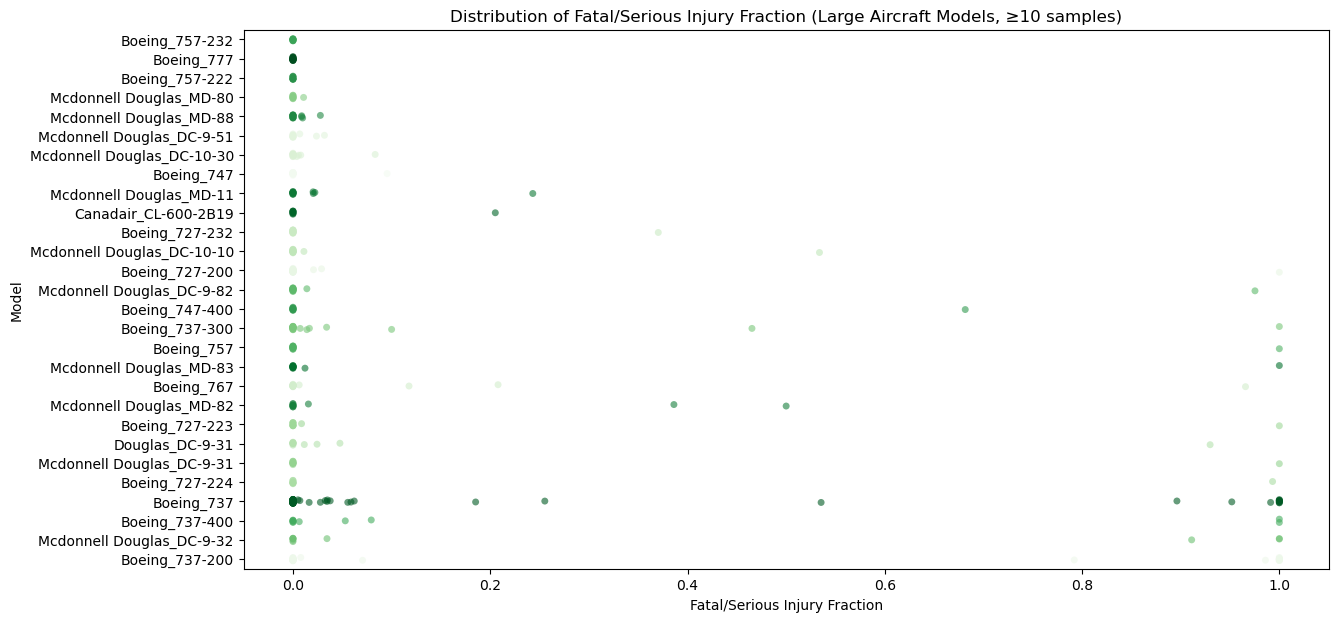

In [21]:
#Count how many records each large aircraft model has
large_model_counts = large_aircraft["Make_Model"].value_counts()

#Keep only models with at least 10 accidents (for statistical reliability)
valid_large_models = large_model_counts[large_model_counts >= 10].index
large_models_filtered = large_aircraft[large_aircraft["Make_Model"].isin(valid_large_models)]

#Calculate the mean fatal/serious injury fraction per model
large_model_means = (
    large_models_filtered.groupby("Make_Model")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
)

#Plot mean fatal/serious injury fractions for large aircraft models
plt.figure(figsize=(12, 7))
sns.barplot(
    x=large_model_means.values,
    y=large_model_means.index,
    color="lightgreen"
)
plt.title("Large Aircraft Models: Mean Fatal/Serious Injury Fraction (≥10 samples)")
plt.xlabel("Mean Fatal/Serious Fraction")
plt.ylabel("Model")
plt.show()

#Plot distribution of fatal/serious injury fractions for each model
#Stripplot shows individual accident outcomes, highlighting variability
plt.figure(figsize=(14, 7))
sns.stripplot(
    data=large_models_filtered,
    x="FatalSerious_Fraction",
    y="Make_Model",
    order=large_model_means.index,
    hue="Make_Model",  
    legend=False,       # suppress redundant legend
    palette="Greens",
    jitter=True,        # spread points for visibility
    alpha=0.6           # transparency for overlapping points
)
plt.title("Distribution of Fatal/Serious Injury Fraction (Large Aircraft Models, ≥10 samples)")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Model")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

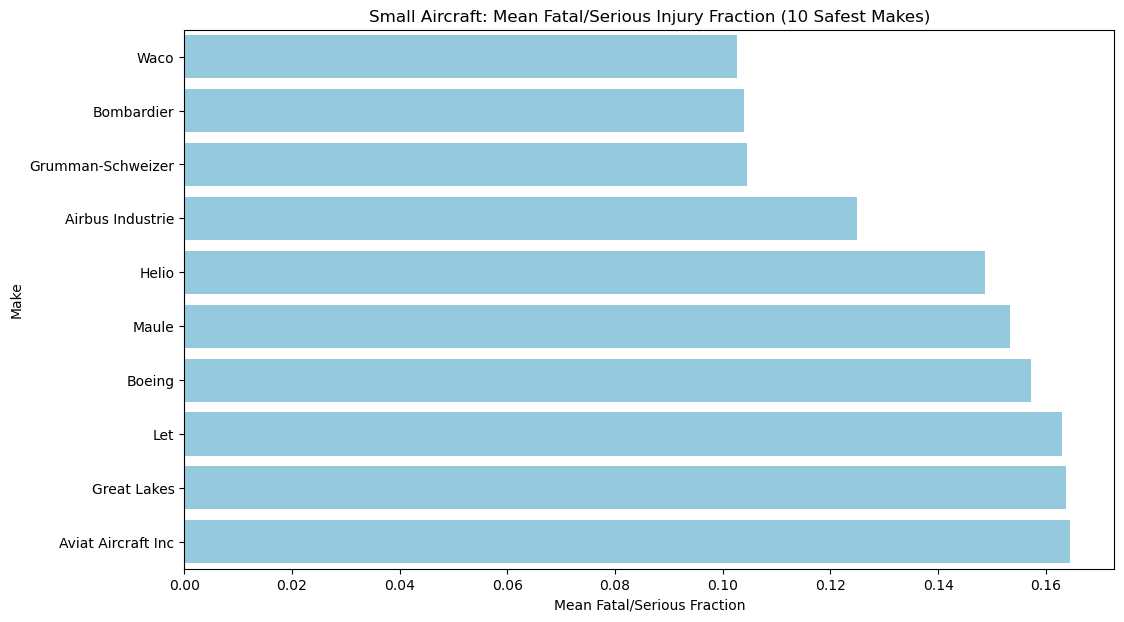

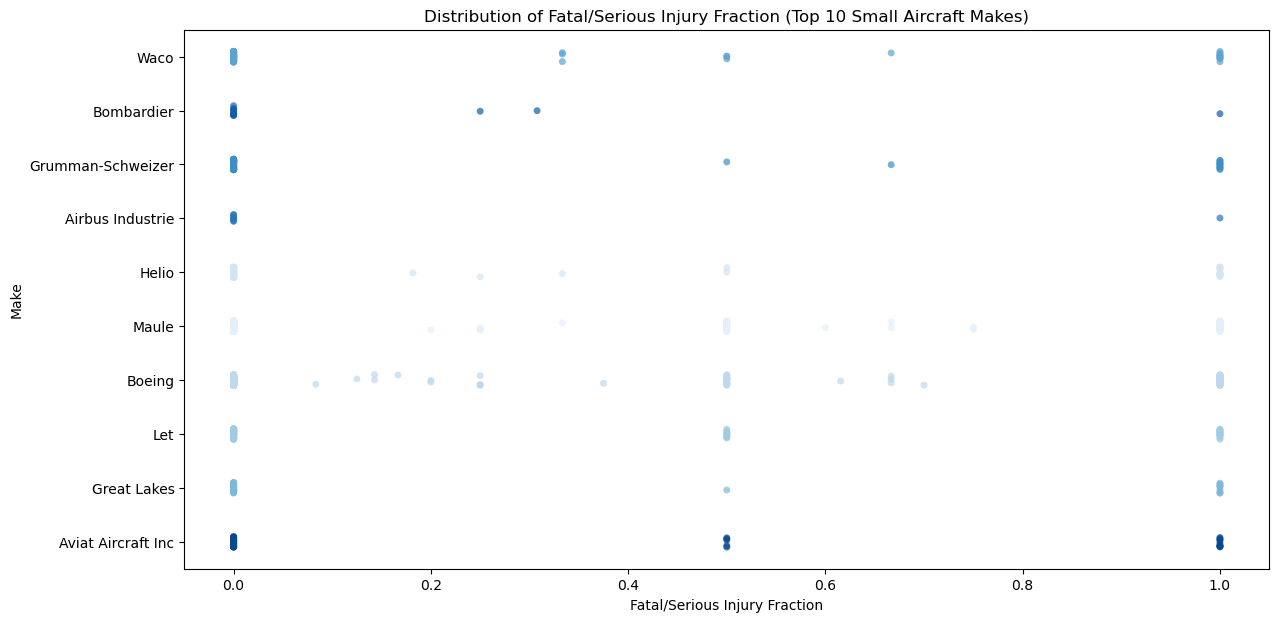

In [22]:
# Calculate mean fatal/serious injury fraction per small aircraft make
small_make_means = (
    small_aircraft.groupby("Make")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
    .head(10)   # keep only the 10 makes with lowest mean fractions
)

# Filter dataset to only include these 10 makes
top_small_makes = small_aircraft[small_aircraft["Make"].isin(small_make_means.index)]

# Plot mean fatal/serious injury fractions for the 10 safest small aircraft makes
plt.figure(figsize=(12, 7))
sns.barplot(
    x=small_make_means.values,
    y=small_make_means.index,
    color="skyblue"
)
plt.title("Small Aircraft: Mean Fatal/Serious Injury Fraction (10 Safest Makes)")
plt.xlabel("Mean Fatal/Serious Fraction")
plt.ylabel("Make")
plt.show()

# Plot distribution of fatal/serious injury fractions for these makes
# Stripplot shows individual accident outcomes, highlighting variability
plt.figure(figsize=(14, 7))
sns.stripplot(
    data=top_small_makes,
    x="FatalSerious_Fraction",
    y="Make",
    order=small_make_means.index,
    hue="Make",        
    legend=False,      
    palette="Blues",
    jitter=True,       
    alpha=0.7       
)
plt.title("Distribution of Fatal/Serious Injury Fraction (Top 10 Small Aircraft Makes)")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Make")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [23]:
''' 
Large Aircraft Models
    - The analysis of large aircraft models (≥10 samples) shows that Boeing 757 variants, Boeing 777, McDonnell Douglas MD‑80/MD‑88, and Canadair CL‑600 consistently have very low mean fatal/serious injury fractions.
    - The distribution plots confirm that most incidents cluster near zero, meaning passengers were rarely fatally or seriously injured.
    - Occasional outliers exist (e.g., DC‑10 and 727 variants), but overall the safety performance of large commercial jets is highly consistent.
    - This reflects the robust engineering and regulatory standards applied to large passenger aircraft.
Small Aircraft Makes
    - Among small aircraft, the 10 safest makes include Waco, Bombardier, Grumman‑Schweizer, Helio, Maule, Aviat, Airbus Industrie, Boeing (small models), Let, and Great Lakes.
    - These makes show the lowest mean fatal/serious injury fractions, but the distribution plots reveal more variability compared to large aircraft.
    - Many incidents cluster at zero (no serious injuries), but some accidents result in complete fatal/serious injury outcomes (fractions near 1.0).
    - This bimodal pattern highlights that small aircraft accidents are more variable in severity, with some makes consistently safer but still vulnerable to catastrophic outcomes.

- Large aircraft models are generally safer and more consistent in passenger outcomes, with tightly clustered distributions near zero.
- Small aircraft makes show greater variability, but several stand out as safer choices (Waco, Bombardier, Grumman‑Schweizer, Helio, Maule).
'''

' \nLarge Aircraft Models\n    - The analysis of large aircraft models (≥10 samples) shows that Boeing 757 variants, Boeing 777, McDonnell Douglas MD‑80/MD‑88, and Canadair CL‑600 consistently have very low mean fatal/serious injury fractions.\n    - The distribution plots confirm that most incidents cluster near zero, meaning passengers were rarely fatally or seriously injured.\n    - Occasional outliers exist (e.g., DC‑10 and 727 variants), but overall the safety performance of large commercial jets is highly consistent.\n    - This reflects the robust engineering and regulatory standards applied to large passenger aircraft.\nSmall Aircraft Makes\n    - Among small aircraft, the 10 safest makes include Waco, Bombardier, Grumman‑Schweizer, Helio, Maule, Aviat, Airbus Industrie, Boeing (small models), Let, and Great Lakes.\n    - These makes show the lowest mean fatal/serious injury fractions, but the distribution plots reveal more variability compared to large aircraft.\n    - Many in

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

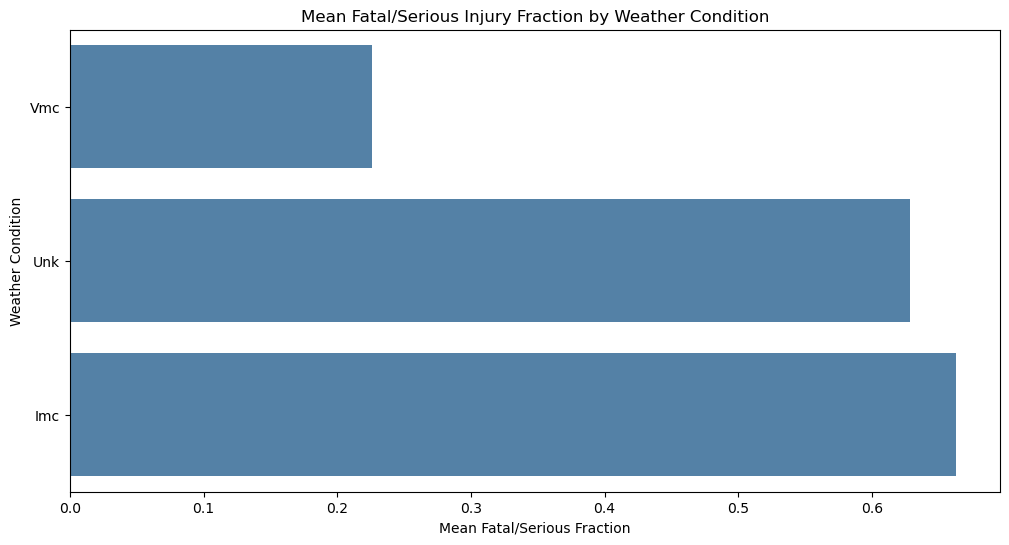

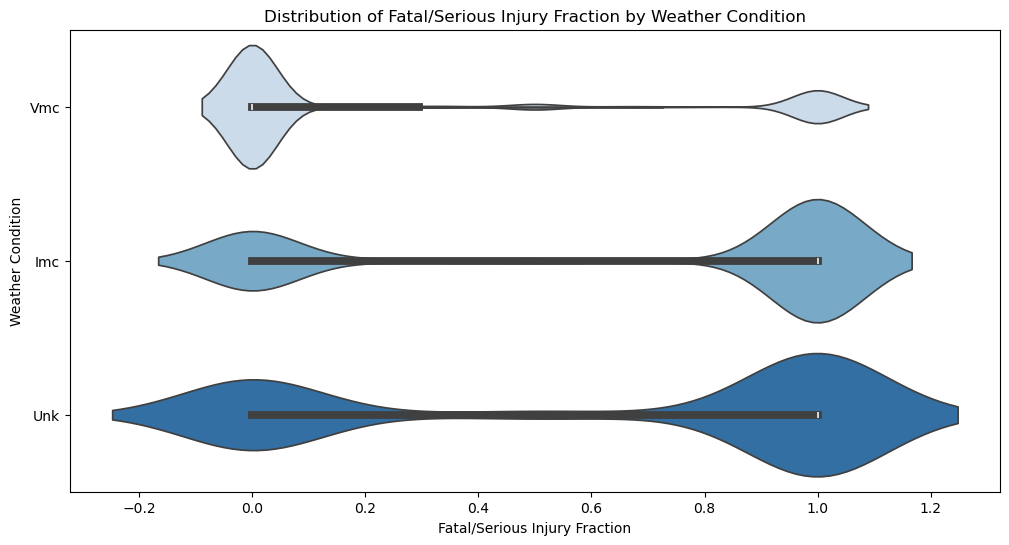

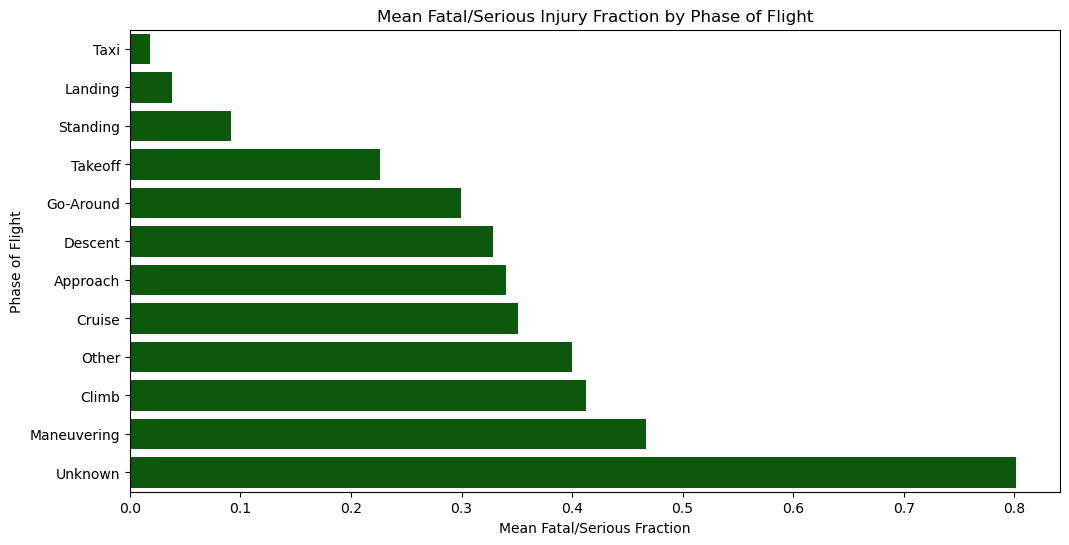

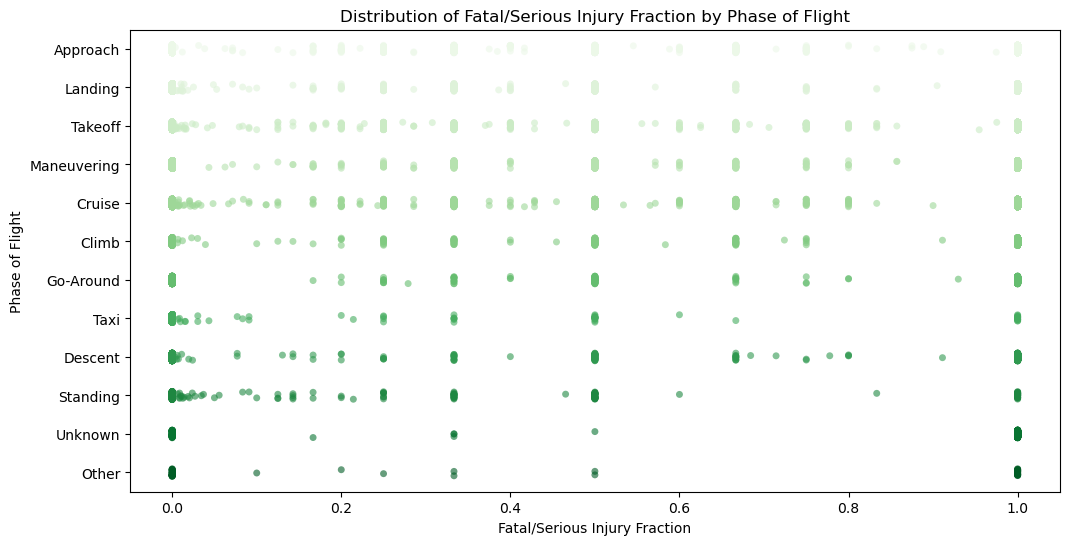

' \nWeather Condition\n Findings from barplot:\n    - VMC (Visual Meteorological Conditions) accidents have the lowest mean fatal/serious injury fraction (~0.23).\n    - IMC (Instrument Meteorological Conditions) and Unknown conditions show much higher averages (~0.63–0.66).\n Findings from violin plot:\n    - In VMC, most accidents cluster near zero, meaning survivable outcomes are more common.\n    - IMC and Unknown conditions show broader distributions, with many accidents resulting in severe injury fractions.\nInterpretation: Poor or uncertain weather conditions significantly increase accident severity, confirming the importance of visibility and weather hazards in aviation safety.\n\nPhase of Flight\n Findings from barplot:\n    - Taxi, Standing, and Landing phases show the lowest mean fatal/serious injury fractions.\n    - Maneuvering and Unknown phases have the highest averages, indicating greater risk.\n Findings from stripplot:\n    - Takeoff, Approach, and Maneuvering phases 

In [24]:

# Factor 1: Weather Condition

# Group accidents by Weather.Condition
# For each weather category, calculate the mean fatal/serious injury fraction
weather_means = (
    aviation_data.groupby("Weather.Condition")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
)

# Plot the mean fatal/serious injury fraction by weather condition
plt.figure(figsize=(12, 6))
sns.barplot(
    x=weather_means.values,   # mean values
    y=weather_means.index,    # weather categories
    color="steelblue"
)
plt.title("Mean Fatal/Serious Injury Fraction by Weather Condition")
plt.xlabel("Mean Fatal/Serious Fraction")
plt.ylabel("Weather Condition")
plt.show()

# Distributional plot (violinplot) to show spread of injury fractions
# This highlights variability within each weather category
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=aviation_data,
    x="FatalSerious_Fraction",
    y="Weather.Condition",
    hue="Weather.Condition",
    legend=False,
    palette="Blues"
)
plt.title("Distribution of Fatal/Serious Injury Fraction by Weather Condition")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Weather Condition")
plt.show()

# Factor 2: Phase of Flight

# Group accidents by Broad.phase.of.flight
# For each flight phase, calculate the mean fatal/serious injury fraction
phase_means = (
    aviation_data.groupby("Broad.phase.of.flight")["FatalSerious_Fraction"]
    .mean()
    .sort_values()
)

# Plot the mean fatal/serious injury fraction by phase of flight
plt.figure(figsize=(12, 6))
sns.barplot(
    x=phase_means.values,   # mean values
    y=phase_means.index,  # flight phases
    color="darkgreen"
)
plt.title("Mean Fatal/Serious Injury Fraction by Phase of Flight")
plt.xlabel("Mean Fatal/Serious Fraction")
plt.ylabel("Phase of Flight")
plt.show()

# Distributional plot (stripplot) to show individual accident outcomes
# This reveals whether certain phases have consistently low/high fractions
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=aviation_data,
    x="FatalSerious_Fraction",
    y="Broad.phase.of.flight",
    jitter=True,       # spread points for visibility
    alpha=0.6,  # transparency for overlapping points
    hue="Broad.phase.of.flight",  
    legend=False,
    palette="Greens"
)
plt.title("Distribution of Fatal/Serious Injury Fraction by Phase of Flight")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Phase of Flight")
plt.show()

''' 
Weather Condition
 Findings from barplot:
    - VMC (Visual Meteorological Conditions) accidents have the lowest mean fatal/serious injury fraction (~0.23).
    - IMC (Instrument Meteorological Conditions) and Unknown conditions show much higher averages (~0.63–0.66).
 Findings from violin plot:
    - In VMC, most accidents cluster near zero, meaning survivable outcomes are more common.
    - IMC and Unknown conditions show broader distributions, with many accidents resulting in severe injury fractions.
Interpretation: Poor or uncertain weather conditions significantly increase accident severity, confirming the importance of visibility and weather hazards in aviation safety.

Phase of Flight
 Findings from barplot:
    - Taxi, Standing, and Landing phases show the lowest mean fatal/serious injury fractions.
    - Maneuvering and Unknown phases have the highest averages, indicating greater risk.
 Findings from stripplot:
    - Takeoff, Approach, and Maneuvering phases show wide spreads, with many accidents clustering near 1.0 (catastrophic outcomes).
    - Cruise accidents are more often survivable, clustering near zero.
Interpretation: Critical phases (takeoff, approach, maneuvering) carry higher risk of severe outcomes, while ground operations (taxi, standing) and cruise are relatively safer.

By analyzing Weather Condition and Phase of Flight, it can be seen that:
- Environmental factors (weather) and operational context (phase of flight) strongly influence accident severity.
- Even safe aircraft models can have severe outcomes under poor weather or during critical flight phases

'''